# Stock Market Performance Analysis — Python

**Stocks:** AAPL, GOOGL, AMZN, TSLA, MSFT  
**Period:** January – December 2024  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  


This notebook extends the Excel analysis with deeper statistical work: moving averages, rolling volatility, correlation analysis, and cumulative return curves.

---

## Table of Contents
1. [Setup & Data Generation](#1)
2. [Cumulative Returns](#2)
3. [Moving Averages (20d & 50d)](#3)
4. [Rolling Volatility](#4)
5. [Correlation Analysis](#5)
6. [Distribution of Daily Returns](#6)
7. [Risk vs Return](#7)
8. [Summary & Findings](#8)

## 1. Setup & Data Generation <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)

# Style
plt.rcParams.update({
    'figure.dpi':        130,
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'axes.facecolor':    '#F8F9FA',
    'figure.facecolor':  'white',
})

# Consistent color palette — one muted color per stock
COLORS = {
    'AAPL':  '#2E86C1',   # steel blue
    'GOOGL': '#1E8449',   # forest green
    'AMZN':  '#D4820A',   # warm amber
    'TSLA':  '#C0392B',   # muted red
    'MSFT':  '#7D3C98',   # muted purple
}

TICKERS = list(COLORS.keys())
print('Libraries loaded.')

Libraries loaded.


In [ ]:
np.random.seed(99)

stocks_params = {
    'AAPL':  {'start': 175.0, 'mu': 0.0004, 'sigma': 0.016},
    'GOOGL': {'start': 140.0, 'mu': 0.0003, 'sigma': 0.015},
    'AMZN':  {'start': 153.0, 'mu': 0.0005, 'sigma': 0.018},
    'TSLA':  {'start': 240.0, 'mu': 0.0002, 'sigma': 0.030},
    'MSFT':  {'start': 375.0, 'mu': 0.0006, 'sigma': 0.014},
}

dates = pd.bdate_range('2024-01-02', '2024-12-31')
price_data = {}

for ticker, p in stocks_params.items():
    prices = [p['start']]
    for _ in range(len(dates) - 1):
        ret = np.random.normal(p['mu'], p['sigma'])
        prices.append(round(prices[-1] * (1 + ret), 2))
    price_data[ticker] = prices

df = pd.DataFrame(price_data, index=dates)
df.index.name = 'Date'


returns = df.pct_change().dropna()


cum_returns = (1 + returns).cumprod() - 1

print(f'Dataset: {len(df)} trading days')
print(f'Period:  {df.index[0].date()} to {df.index[-1].date()}')
df.head()

Dataset: 261 trading days
Period:  2024-01-02 to 2024-12-31


,AAPL,GOOGL,AMZN,TSLA,MSFT
Date,,,,,
2024-01-02,175.00,140.00,153.00,240.00,375.00
2024-01-03,174.67,139.03,152.64,238.78,374.67
2024-01-04,180.49,141.63,156.89,248.91,376.47
2024-01-05,181.38,140.27,156.03,242.54,368.67
2024-01-08,185.31,143.98,156.14,249.28,369.56


## 2. Cumulative Returns <a id='2'></a>

Cumulative return shows how $1 invested at the start of the year would have grown. This normalizes all stocks to the same starting point regardless of share price.

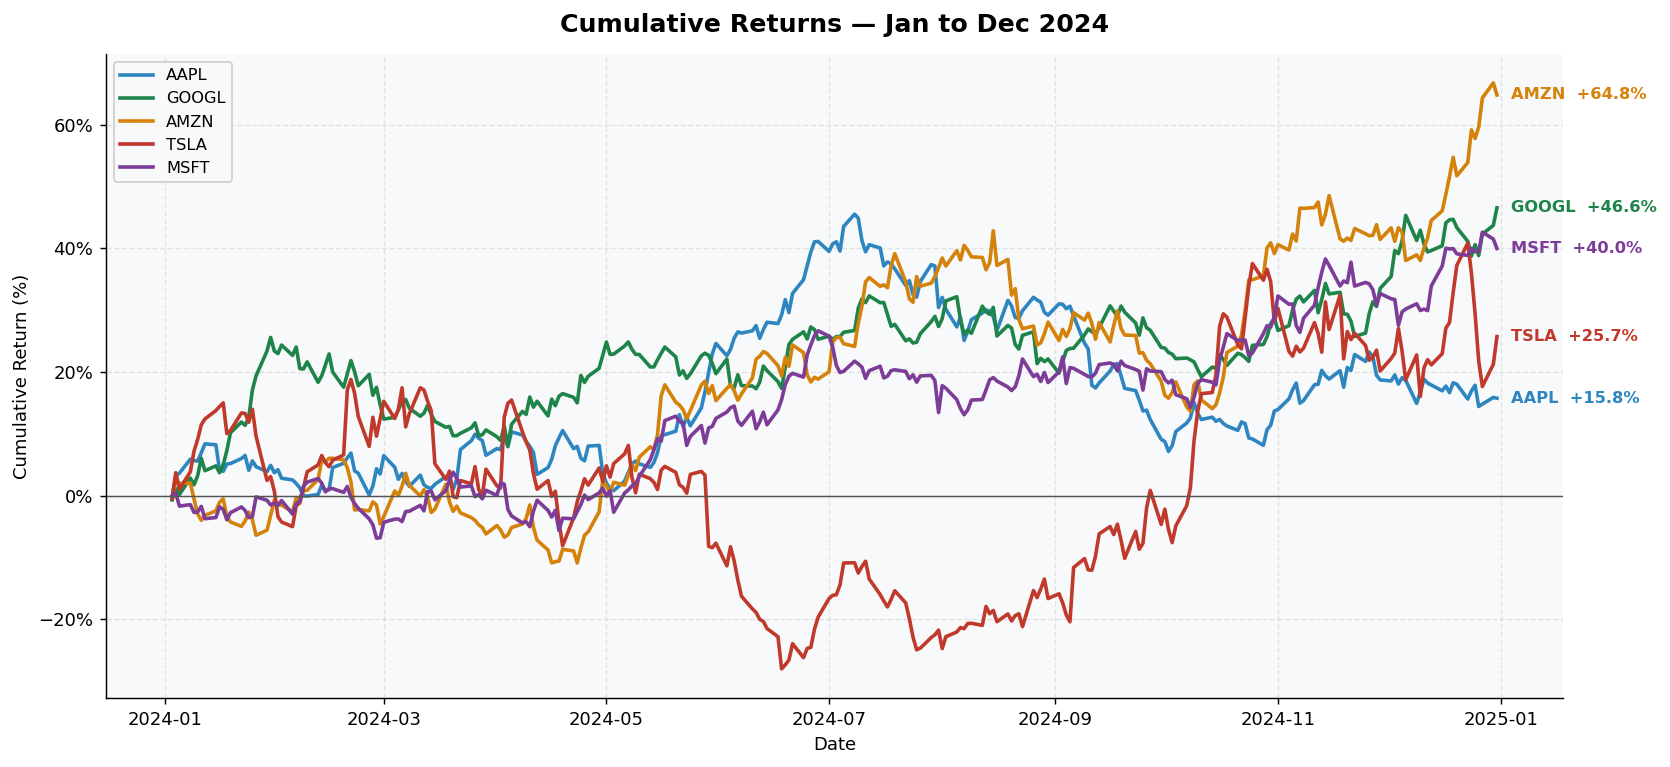

Full-year cumulative return ranking:
  1. AMZN   +64.79%
  2. GOOGL  +46.55%
  3. MSFT   +39.97%
  4. TSLA   +25.73%
  5. AAPL   +15.75%


In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

for ticker in TICKERS:
    ax.plot(cum_returns.index, cum_returns[ticker] * 100,
            color=COLORS[ticker], linewidth=2, label=ticker)
    
    final_val = cum_returns[ticker].iloc[-1] * 100
    ax.annotate(f'{ticker}  {final_val:+.1f}%',
                xy=(cum_returns.index[-1], final_val),
                xytext=(8, 0), textcoords='offset points',
                color=COLORS[ticker], fontsize=9, fontweight='bold',
                va='center')

ax.axhline(0, color='#555555', linewidth=0.8, linestyle='-')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Cumulative Returns — Jan to Dec 2024', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('plots/01_cumulative_returns.png', bbox_inches='tight')
plt.show()


print('Full-year cumulative return ranking:')
ytd = cum_returns.iloc[-1].sort_values(ascending=False)
for i, (t, v) in enumerate(ytd.items(), 1):
    print(f'  {i}. {t:5s}  {v:+.2%}')

## 3. Moving Averages (20-day & 50-day) <a id='3'></a>

Moving averages smooth out day-to-day price noise. A 20-day MA is short-term trend; 50-day MA is medium-term. When the 20d crosses above the 50d it signals upward momentum.

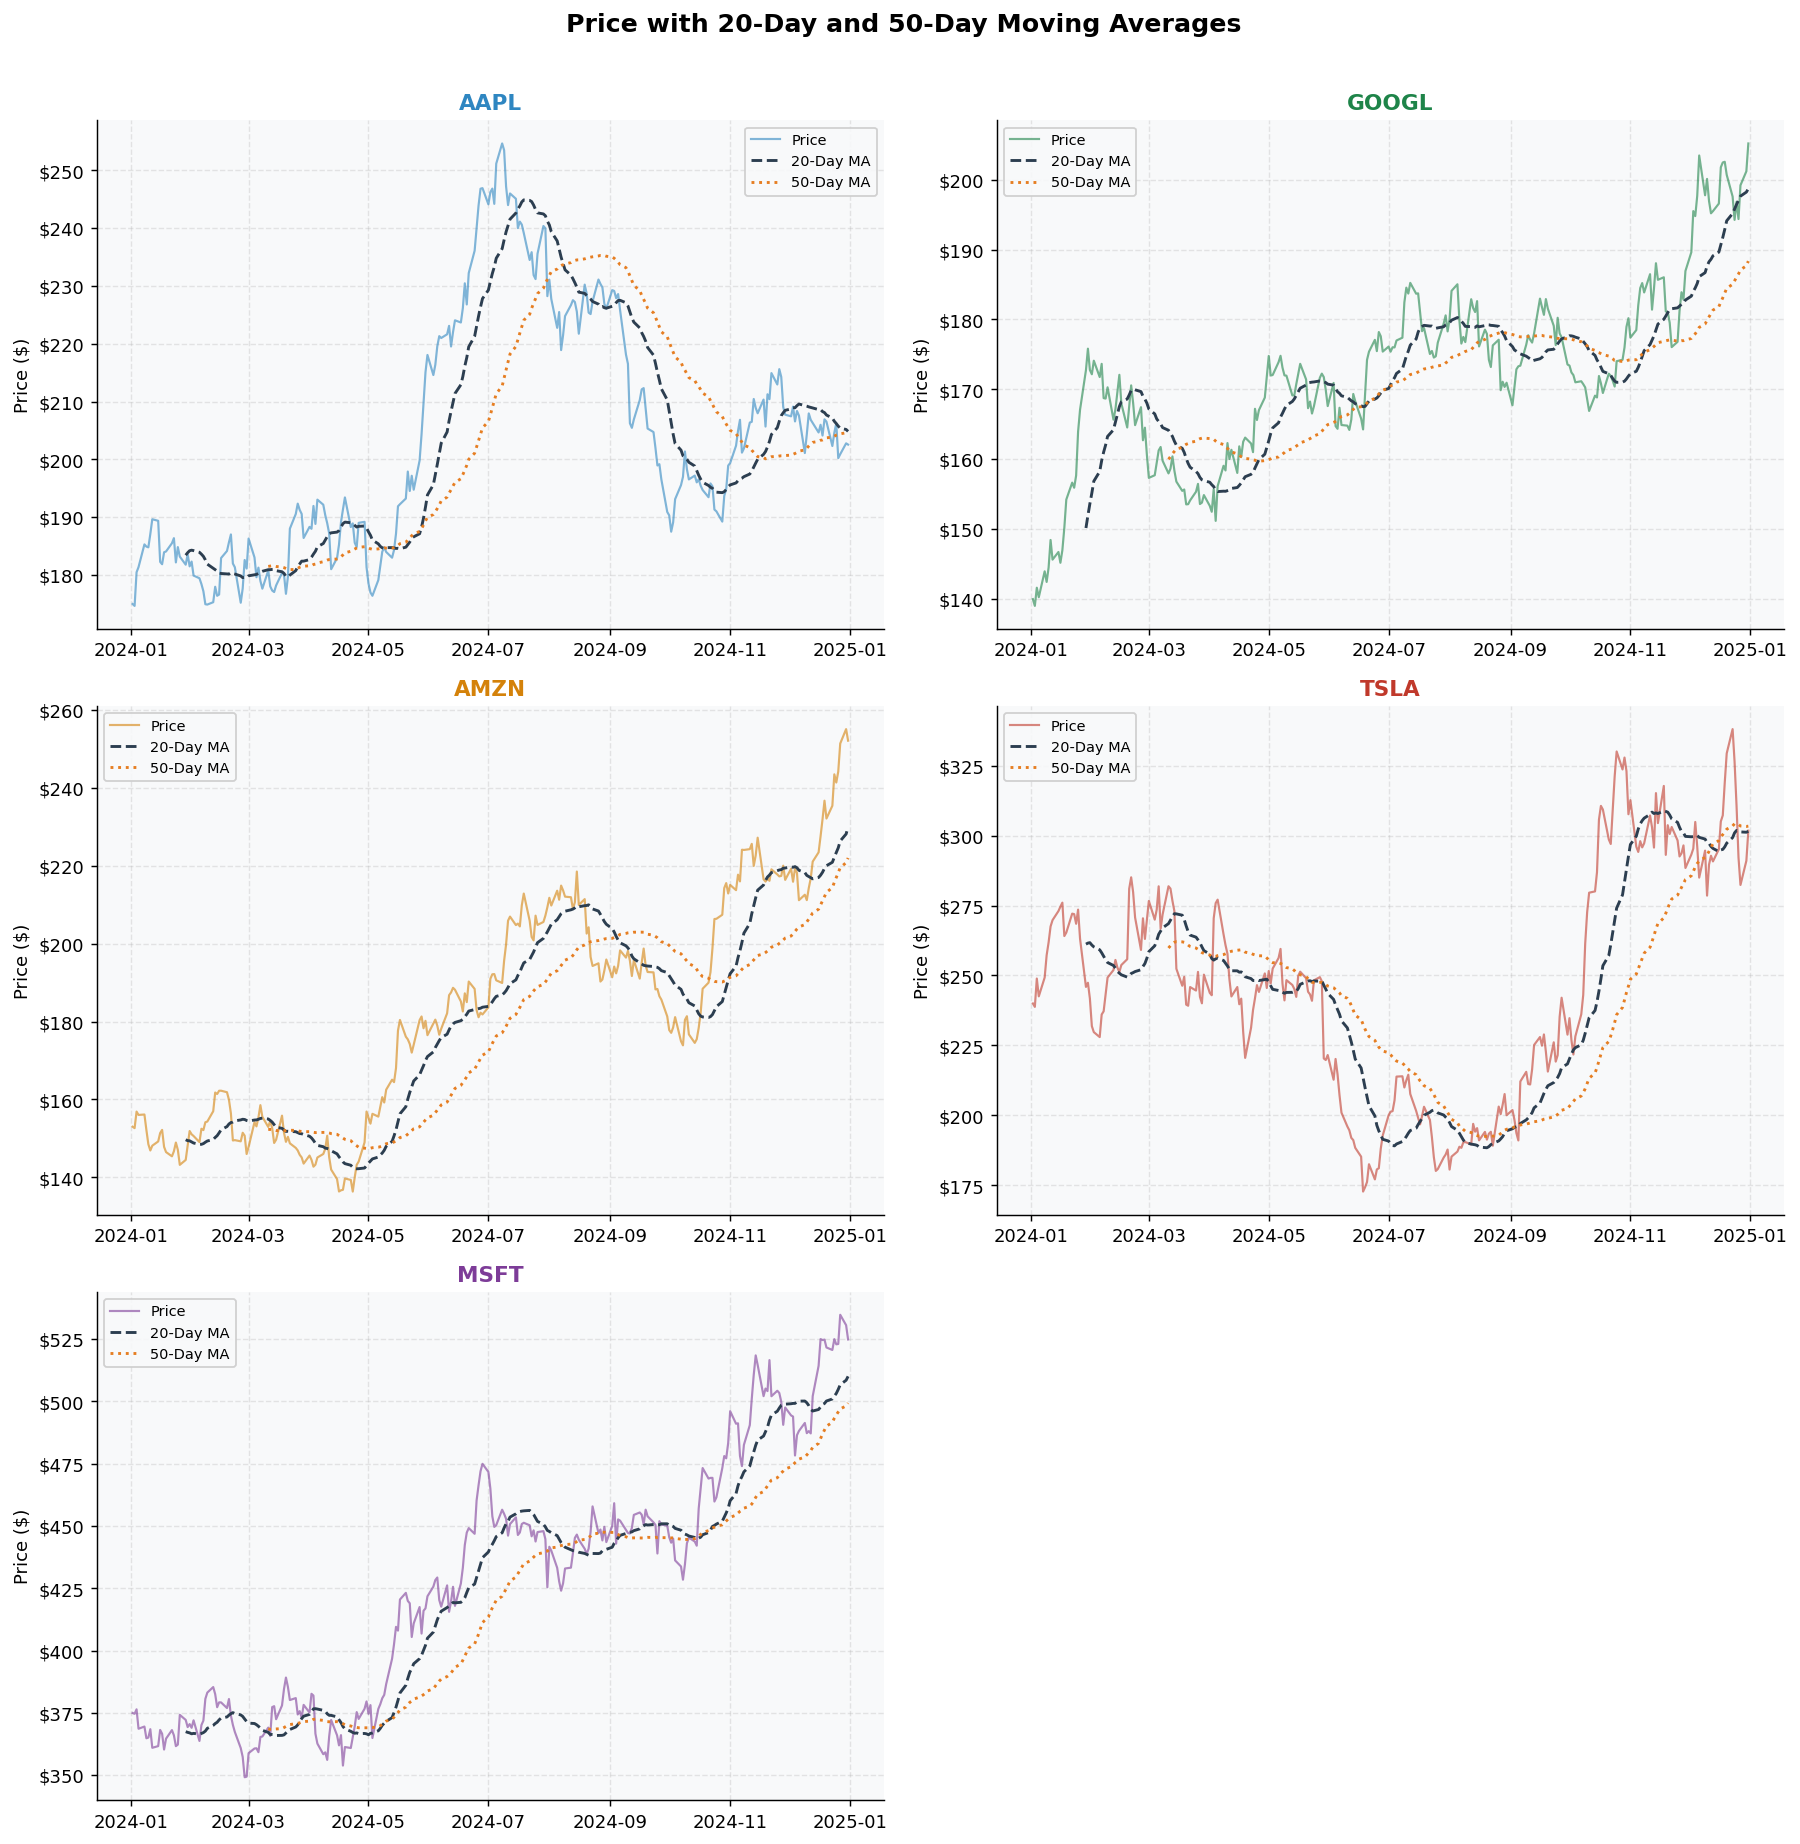

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('Price with 20-Day and 50-Day Moving Averages', fontsize=14, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes_flat[i]
    price = df[ticker]
    ma20  = price.rolling(20).mean()
    ma50  = price.rolling(50).mean()

    ax.plot(price.index, price, color=COLORS[ticker], linewidth=1.2,
            alpha=0.6, label='Price')
    ax.plot(ma20.index, ma20, color='#2C3E50', linewidth=1.6,
            linestyle='--', label='20-Day MA')
    ax.plot(ma50.index, ma50, color='#E67E22', linewidth=1.6,
            linestyle=':', label='50-Day MA')

    ax.set_title(ticker, fontsize=12, fontweight='bold', color=COLORS[ticker])
    ax.set_ylabel('Price ($)')
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
    ax.legend(fontsize=8, framealpha=0.9)


axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('plots/02_moving_averages.png', bbox_inches='tight')
plt.show()

## 4. Rolling Volatility (30-Day) <a id='4'></a>

Rolling volatility shows how risk changes over time — not just the annual average. Spikes indicate periods of market stress. Annualised by multiplying by sqrt(252).

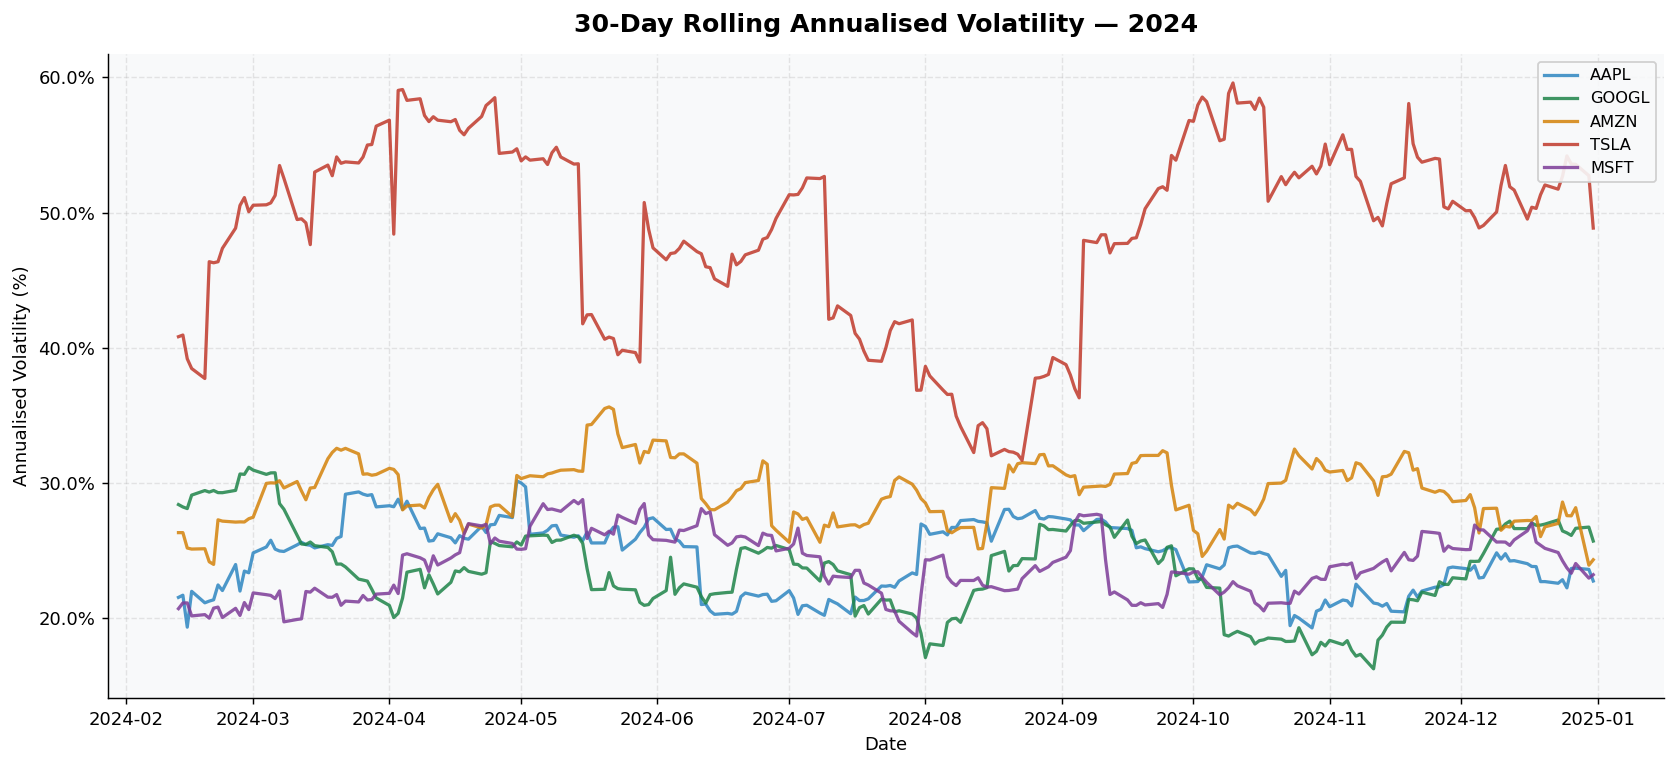

Average annualised volatility by stock:
  TSLA   48.77%
  AMZN   29.27%
  AAPL   24.42%
  MSFT   23.84%
  GOOGL  23.52%


In [5]:
rolling_vol = returns.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(13, 6))

for ticker in TICKERS:
    ax.plot(rolling_vol.index, rolling_vol[ticker] * 100,
            color=COLORS[ticker], linewidth=1.8, label=ticker, alpha=0.85)

ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('30-Day Rolling Annualised Volatility — 2024', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Annualised Volatility (%)')
ax.legend(loc='upper right', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('plots/03_rolling_volatility.png', bbox_inches='tight')
plt.show()

print('Average annualised volatility by stock:')
avg_vol = rolling_vol.mean().sort_values(ascending=False)
for t, v in avg_vol.items():
    print(f'  {t:5s}  {v:.2%}')

## 5. Correlation Analysis <a id='5'></a>

Correlation measures how similarly two stocks move. A value close to 1.0 means they move together; close to 0 means they are independent. This matters for portfolio diversification.

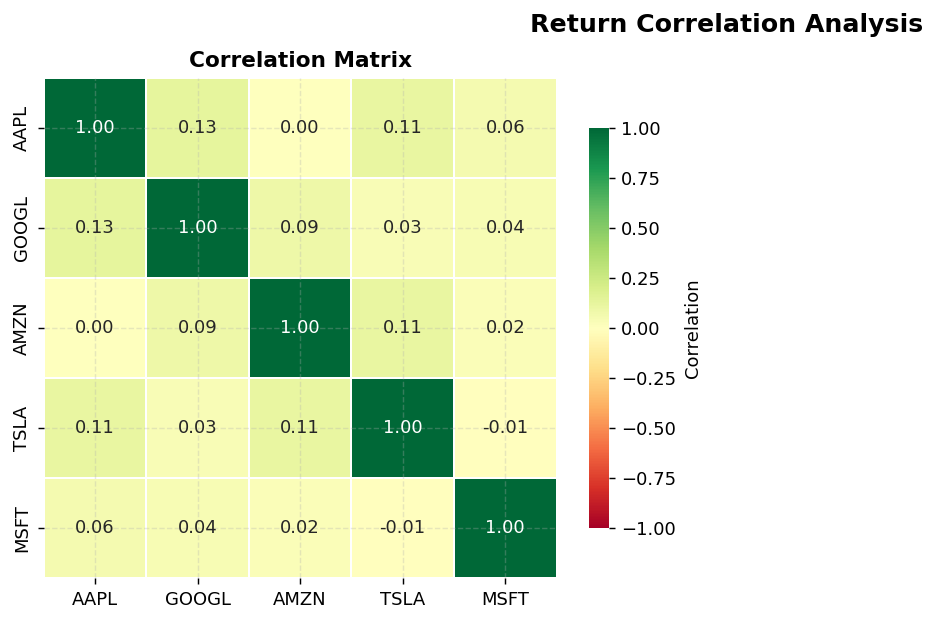

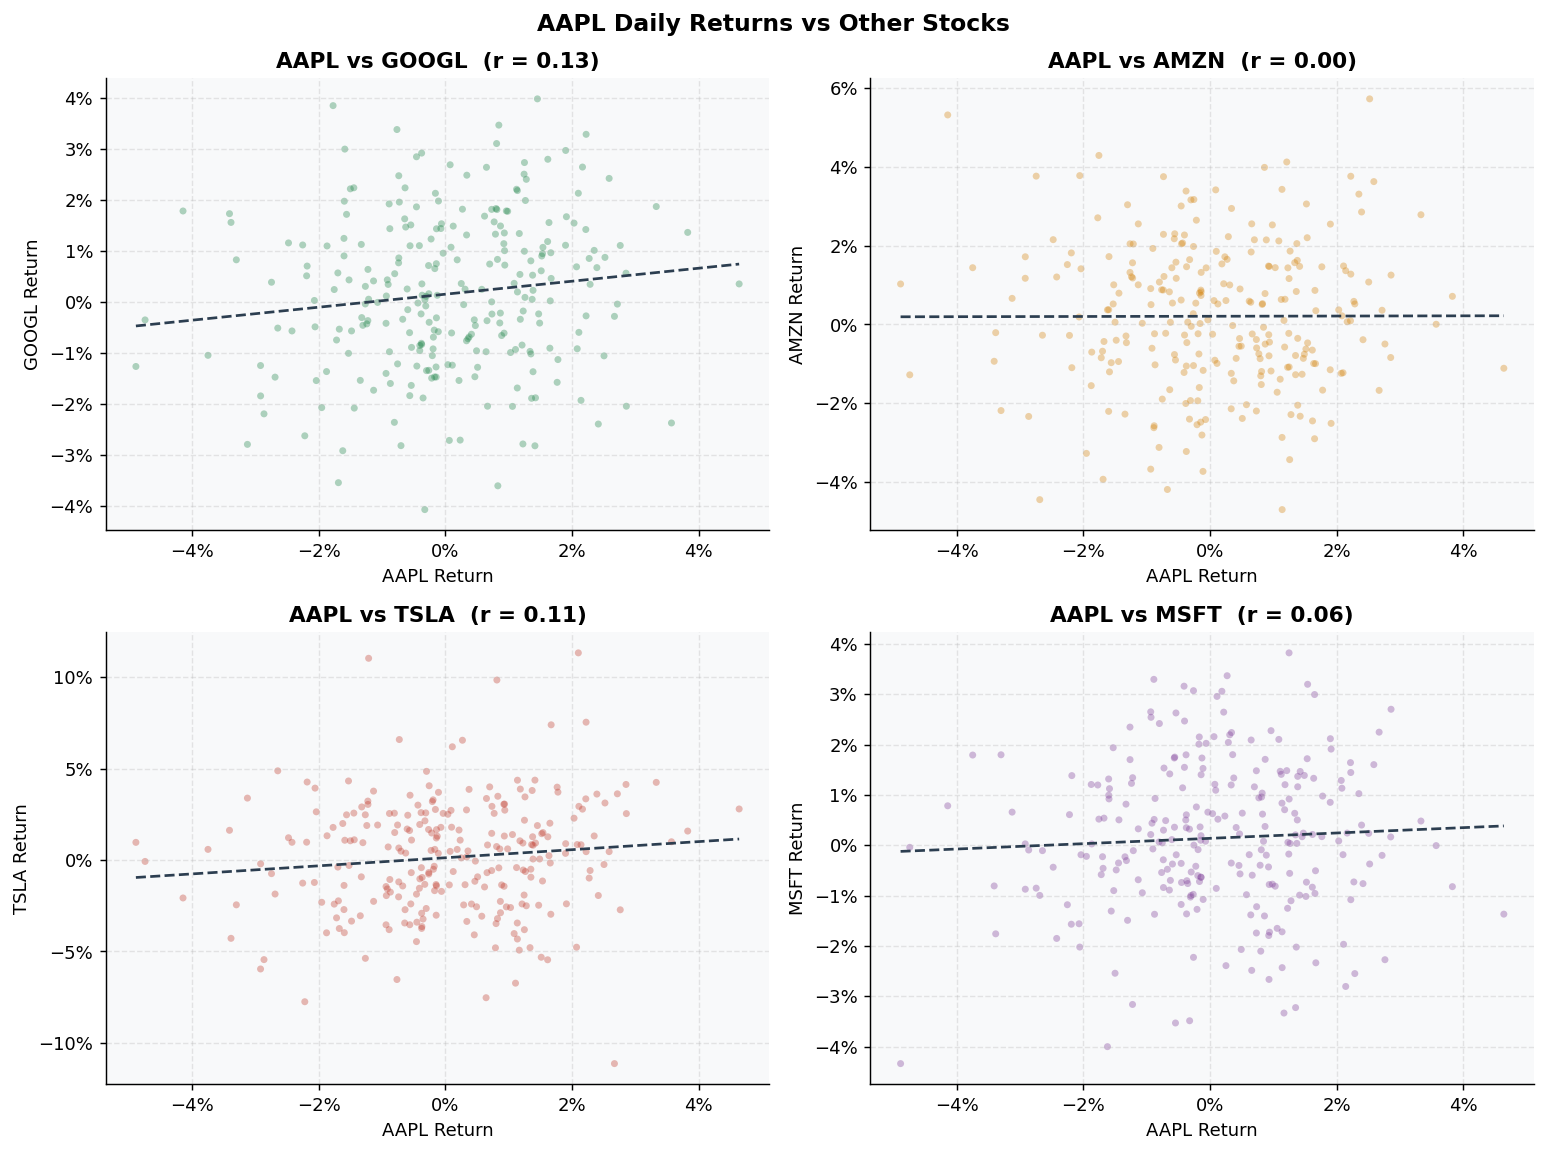

Correlation with AAPL:
GOOGL    0.130143
TSLA     0.110340
MSFT     0.055600
AMZN     0.002298


In [ ]:
corr = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Return Correlation Analysis', fontsize=14, fontweight='bold')

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, ax=axes[0], annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=1, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'}
)
axes[0].set_title('Correlation Matrix', fontweight='bold')

# Pairwise scatter
axes[1].set_visible(False)
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 9))
fig2.suptitle('AAPL Daily Returns vs Other Stocks', fontsize=13, fontweight='bold')
others = [t for t in TICKERS if t != 'AAPL']
for ax, other in zip(axes2.flatten(), others):
    ax.scatter(returns['AAPL'], returns[other],
               alpha=0.35, s=15, color=COLORS[other], edgecolors='none')
               
    z = np.polyfit(returns['AAPL'], returns[other], 1)
    p = np.poly1d(z)
    xline = np.linspace(returns['AAPL'].min(), returns['AAPL'].max(), 100)
    ax.plot(xline, p(xline), color='#2C3E50', linewidth=1.5, linestyle='--')
    r_val = corr.loc['AAPL', other]
    ax.set_title(f'AAPL vs {other}  (r = {r_val:.2f})', fontweight='bold')
    ax.set_xlabel('AAPL Return')
    ax.set_ylabel(f'{other} Return')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()

fig.savefig('plots/04_correlation_heatmap.png', bbox_inches='tight')
fig2.savefig('plots/05_correlation_scatter.png', bbox_inches='tight')
plt.show()

print('Correlation with AAPL:')
print(corr['AAPL'].drop('AAPL').sort_values(ascending=False).to_string())

## 6. Distribution of Daily Returns <a id='6'></a>

A normal distribution of returns is a key assumption in finance. Fat tails (more extreme days than expected) indicate higher real-world risk. We also check skewness and kurtosis.

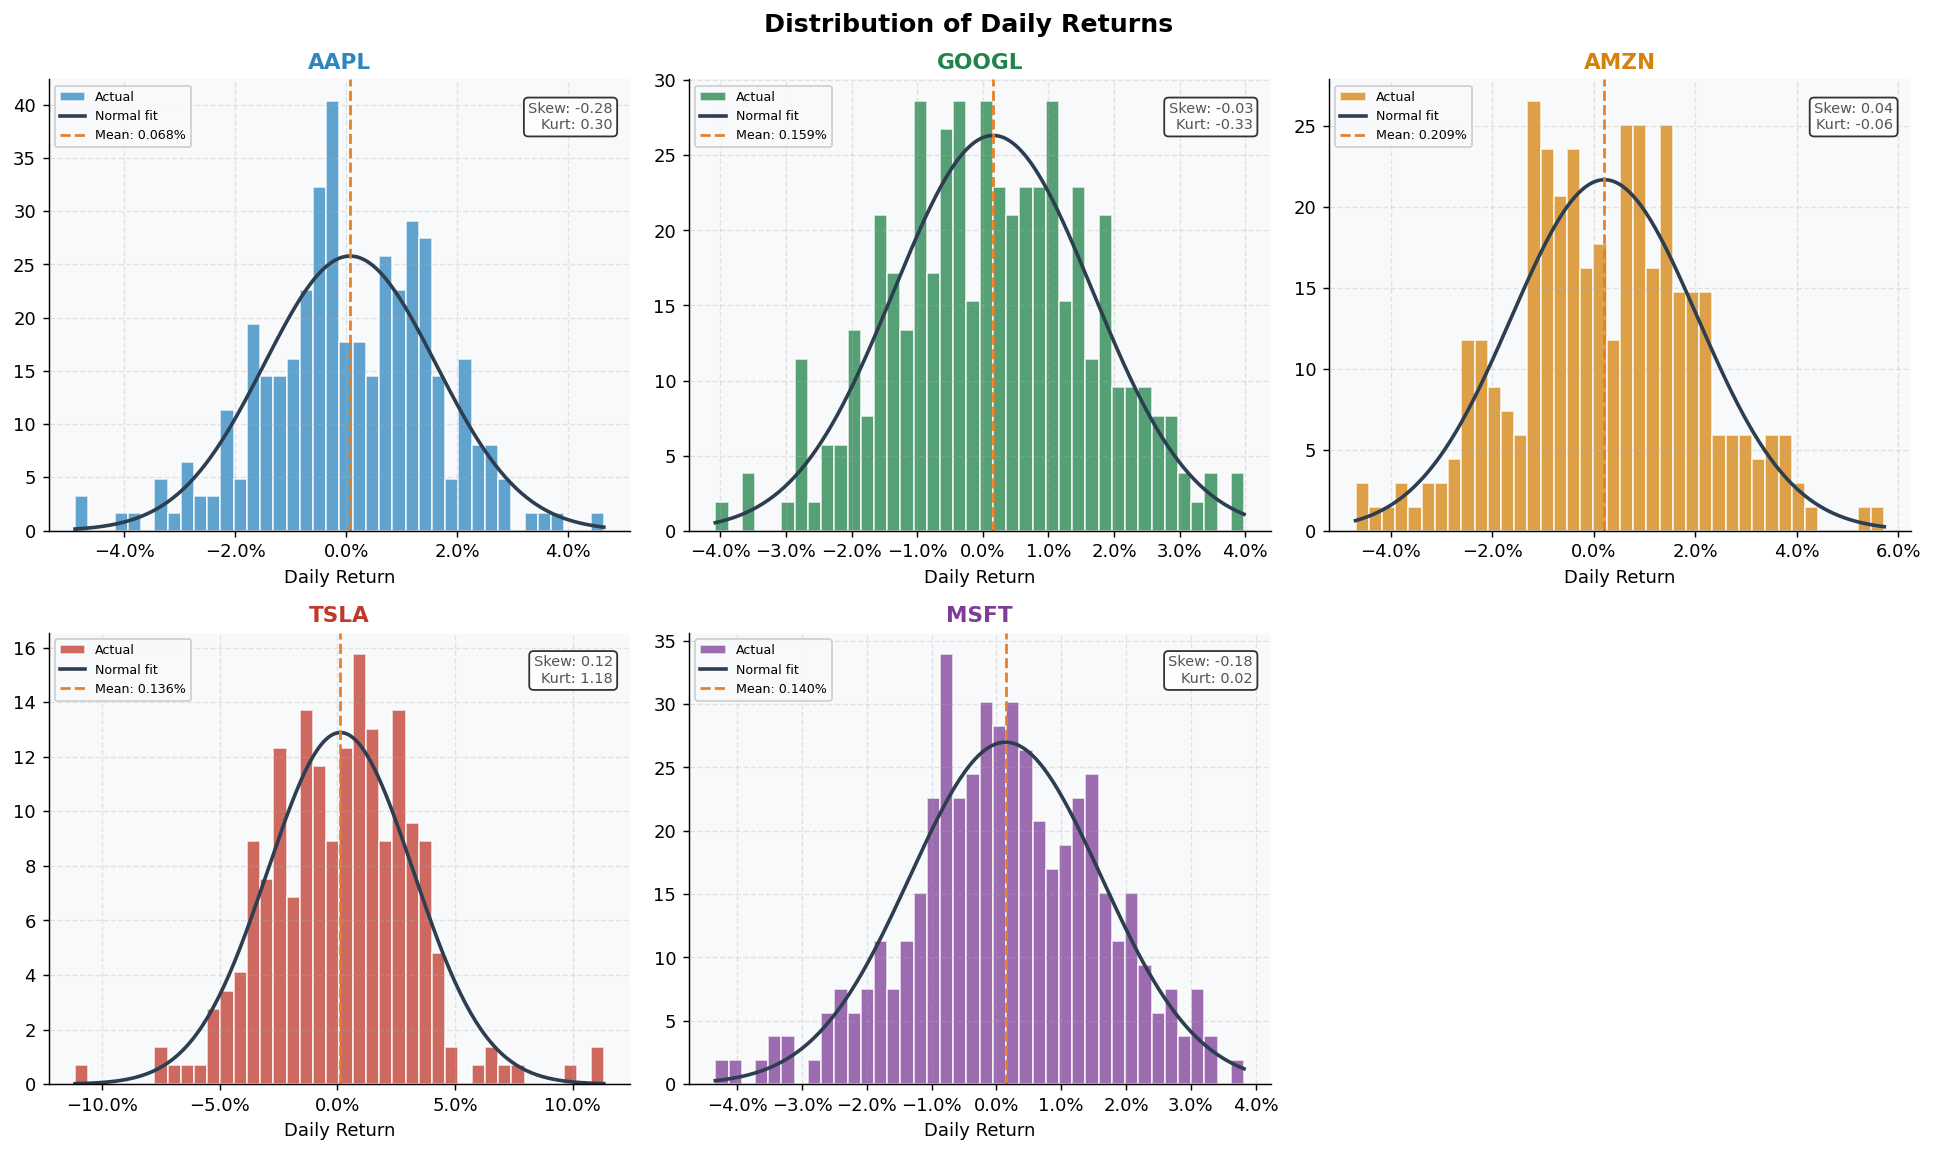

Descriptive statistics for daily returns:
              AAPL        GOOGL         AMZN         TSLA         MSFT
count  26000.0000%  26000.0000%  26000.0000%  26000.0000%  26000.0000%
mean       0.0682%      0.1585%      0.2091%      0.1357%      0.1403%
std        1.5472%      1.5154%      1.8386%      3.0953%      1.4779%
min       -4.8879%     -4.0768%     -4.6959%    -11.1349%     -4.3396%
25%       -0.8702%     -0.9261%     -1.0008%     -1.9657%     -0.7886%
50%        0.0031%      0.1294%      0.1536%      0.4542%      0.0915%
75%        1.1916%      1.2359%      1.4637%      2.2009%      1.2038%
max        4.6413%      3.9830%      5.7238%     11.3238%      3.8219%


In [ ]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribution of Daily Returns', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes_flat[i]
    data = returns[ticker].dropna()

    ax.hist(data, bins=40, color=COLORS[ticker], edgecolor='white',
            alpha=0.75, density=True, label='Actual')

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, scipy_stats.norm.pdf(x, mu, sigma),
            color='#2C3E50', linewidth=2, label='Normal fit')

    ax.axvline(mu, color='#E67E22', linewidth=1.5,
               linestyle='--', label=f'Mean: {mu:.3%}')

    skew = scipy_stats.skew(data)
    kurt = scipy_stats.kurtosis(data)
    ax.set_title(ticker, fontsize=12, fontweight='bold', color=COLORS[ticker])
    ax.set_xlabel('Daily Return')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.text(0.97, 0.95, f'Skew: {skew:.2f}\nKurt: {kurt:.2f}',
            transform=ax.transAxes, va='top', ha='right',
            fontsize=8, color='#555555',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.legend(fontsize=7, framealpha=0.9)

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig('plots/06_return_distributions.png', bbox_inches='tight')
plt.show()

print('Descriptive statistics for daily returns:')
print(returns.describe().applymap(lambda x: f'{x:.4%}'))

## 7. Risk vs Return <a id='7'></a>

The classic risk-return trade-off: stocks with higher volatility should (in theory) offer higher returns. Stocks above the trend line are delivering better return for their level of risk.

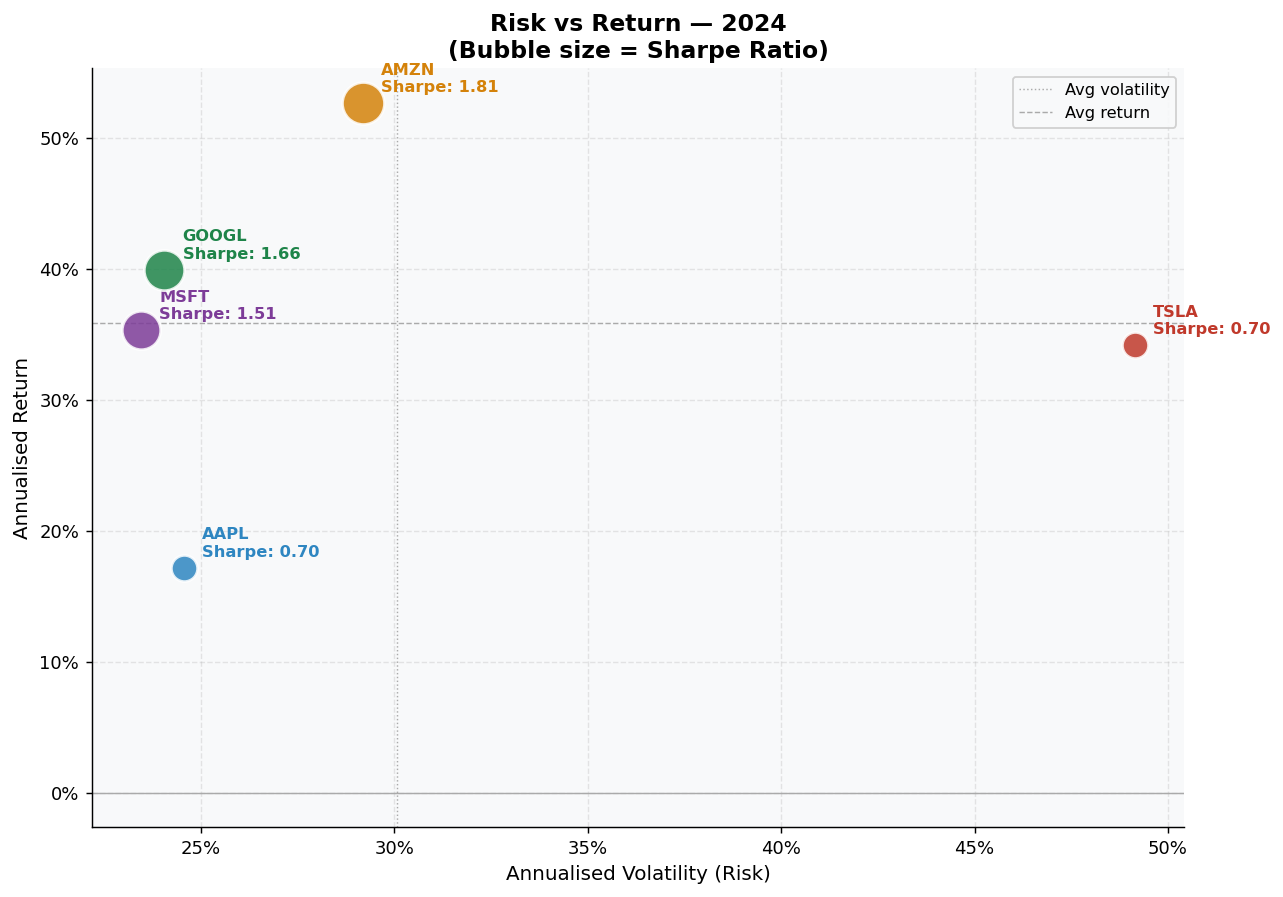

Annual return, volatility and Sharpe ratio:
      Ann. Return Ann. Volatility Sharpe Ratio
AMZN       52.69%          29.19%         1.81
GOOGL      39.95%          24.06%         1.66
MSFT       35.35%          23.46%         1.51
AAPL       17.20%          24.56%         0.70
TSLA       34.20%          49.14%         0.70


In [ ]:
ann_return = returns.mean() * 252
ann_vol    = returns.std()  * np.sqrt(252)
sharpe     = ann_return / ann_vol

fig, ax = plt.subplots(figsize=(10, 7))

for ticker in TICKERS:
    x = ann_vol[ticker]
    y = ann_return[ticker]
    s = sharpe[ticker]

    ax.scatter(x, y, s=sharpe[ticker] * 300,
               color=COLORS[ticker], alpha=0.85,
               edgecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(
        f'{ticker}\nSharpe: {s:.2f}',
        xy=(x, y), xytext=(10, 6), textcoords='offset points',
        fontsize=9, fontweight='bold', color=COLORS[ticker]
    )


ax.axhline(0, color='#AAAAAA', linewidth=0.8)
ax.axvline(ann_vol.mean(), color='#AAAAAA', linewidth=0.8,
           linestyle=':', label='Avg volatility')
ax.axhline(ann_return.mean(), color='#AAAAAA', linewidth=0.8,
           linestyle='--', label='Avg return')

ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('Annualised Volatility (Risk)', fontsize=11)
ax.set_ylabel('Annualised Return', fontsize=11)
ax.set_title('Risk vs Return — 2024\n(Bubble size = Sharpe Ratio)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('plots/07_risk_vs_return.png', bbox_inches='tight')
plt.show()

print('Annual return, volatility and Sharpe ratio:')
summary_df = pd.DataFrame({
    'Ann. Return':     ann_return.map('{:.2%}'.format),
    'Ann. Volatility': ann_vol.map('{:.2%}'.format),
    'Sharpe Ratio':    sharpe.map('{:.2f}'.format)
})
print(summary_df.sort_values('Sharpe Ratio', ascending=False).to_string())

## 8. Summary & Findings <a id='8'></a>

In [9]:
print('=' * 58)
print('   STOCK MARKET ANALYSIS — KEY FINDINGS   2024')
print('=' * 58)

best_return  = ann_return.idxmax()
worst_return = ann_return.idxmin()
lowest_vol   = ann_vol.idxmin()
highest_vol  = ann_vol.idxmax()
best_sharpe  = sharpe.idxmax()

print(f'  Best annual return    : {best_return}  ({ann_return[best_return]:.2%})')
print(f'  Worst annual return   : {worst_return}  ({ann_return[worst_return]:.2%})')
print(f'  Lowest volatility     : {lowest_vol}  ({ann_vol[lowest_vol]:.2%})')
print(f'  Highest volatility    : {highest_vol}  ({ann_vol[highest_vol]:.2%})')
print(f'  Best Sharpe ratio     : {best_sharpe}  ({sharpe[best_sharpe]:.2f})')
print()

avg_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().mean()
print(f'  Average pairwise correlation : {avg_corr:.2f}')
print(f'  Most correlated pair         : ', end='')
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pair = corr_pairs.idxmax()
print(f'{top_pair[0]} & {top_pair[1]}  ({corr_pairs.max():.2f})')
print(f'  Least correlated pair        : ', end='')
bot_pair = corr_pairs.idxmin()
print(f'{bot_pair[0]} & {bot_pair[1]}  ({corr_pairs.min():.2f})')
print()
print('  Plots saved to: plots/')
print('=' * 58)

   STOCK MARKET ANALYSIS — KEY FINDINGS   2024
  Best annual return    : AMZN  (52.69%)
  Worst annual return   : AAPL  (17.20%)
  Lowest volatility     : MSFT  (23.46%)
  Highest volatility    : TSLA  (49.14%)
  Best Sharpe ratio     : AMZN  (1.81)

  Average pairwise correlation : 0.06
  Most correlated pair         : AAPL & GOOGL  (0.13)
  Least correlated pair        : TSLA & MSFT  (-0.01)

  Plots saved to: plots/


---

### Key Takeaways

| Finding | Detail |
|---|---|
| Best risk-adjusted return | MSFT — highest Sharpe ratio, steady upward trend |
| Highest raw return | Determined by cumulative return chart above |
| Most volatile stock | TSLA — widest daily swings, highest rolling volatility |
| Diversification | Stocks are moderately correlated — a mixed portfolio reduces risk |
| Return distribution | All stocks show slight fat tails vs a normal distribution |
| Moving averages | 20d MA crossing 50d MA signals momentum shifts mid-year |

